# Demo 1 — Training a ReMatch model on Balearic wall lizards

Builds a re-identification model from the gallery bundled in `data/` —
**12 individual lizards, 4 photographs each**. [Demo 2](demo-2-query.ipynb) then
uses it to identify 20 new photographs, including animals it has never seen.

The images are ventral scale-pattern crops from the **BalearicLizard** dataset:
4 619 photographs of 1 009 individuals from fifteen years of capture–recapture
monitoring on Illot d'en Curt, Mallorca. The full dataset and its documentation
are published separately:

> Alcaraz, R., Albalat-Oliver, B., Villa, A. *et al.* **A long-term photographic
> dataset for individual identification of the Balearic wall lizard.**
> *Scientific Data* (2026). [doi:10.1038/s41597-026-07411-z](https://doi.org/10.1038/s41597-026-07411-z)
> · [Download from Kaggle](https://www.kaggle.com/datasets/roberalcaraz/baleariclizard)

This is the same method as `scripts/P2`–`P4`, unrolled so you can watch each
stage, reading its configuration from the same `params/` files. For a real
database use those scripts: they cache wireframes and matches to disk and can
resume, which matters once the quadratic matching step gets expensive.

**Where this starts.** The bundled images are already **pattern crops** — the
output of `scripts/P1`, which segments the lizard with YOLO and then isolates the
scale mosaic with SAM + structured edge detection. That stage needs the original
field photographs, which come with the dataset above; the crops are what ReMatch
actually matches on, so the demo begins there.

**Stages**

1. Describe each pattern as a **SuperPoint + LSD wireframe** — keypoints *and*
   line segments.
2. **Match** every pair with GlueStick and reduce each pair to **four features**.
3. Train the **pair-level classifier**, the **identity-level meta-model** and the
   open-set threshold **τ\***.

Matching every pair is the slow step — 1 128 pairs, about a quarter of an hour
on a CPU. So by default the notebook loads the match table bundled in
`data/precomputed/`, produced by the same code, and runs in a couple of
minutes. Set `RUN_MATCHING = True` to compute it yourself.

## Setup

Run this notebook from the repository root.

In [1]:
import os, sys, json
from pathlib import Path

import cv2, numpy as np, pandas as pd, torch, joblib
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd()))          # run from the repository root

import params.params as params
import utils.demo_utils as D

# SuperPoint pads to a fixed keypoint count with random points, so an unseeded
# run picks a different classifier and a different threshold every time.
D.set_seed(0)

# CLAHE contrast enhancement, applied to every image before its wireframe is
# extracted. On by default: this is what `scripts/` does and what the published
# results were produced with. Set it to False to see what it buys you on your
# own photographs. Keep demo-1 and demo-2 on the same setting - the model is
# trained on whatever this produces.
D.ENHANCE_CONTRAST = True

# Matching every pair is the slow step: 1 128 pairs, about a quarter of an hour
# on a CPU. False loads the table bundled in data/precomputed/ instead - made by
# the same code (scripts/make_demo_matches.py). True recomputes it here.
RUN_MATCHING = False
PRECOMPUTED  = Path("data/precomputed/lizard_demo_matches.parquet")

DEVICE  = D.device()          # CUDA if available, else CPU
PATTERN = Path(params.PATTERN_IMAGES_FOLDER)      # data/images-pattern
RESULTS = Path(params.RESULTS_FOLDER)             # results
RESULTS.mkdir(parents=True, exist_ok=True)

# The bundled demo individuals. Drop the filter to train on everything you have.
individuals = sorted(p.name for p in PATTERN.iterdir()
                     if p.is_dir() and p.name.startswith("lizard_"))

print("device      :", DEVICE)
print("patterns    :", PATTERN)
print("results     :", RESULTS)
print("individuals :", len(individuals))
print("images      :", sum(len(D.list_images(PATTERN / i)) for i in individuals))

device      : cpu
patterns    : data/images-pattern
results     : results
individuals : 12
images      : 48


## The gallery

Directory names under `data/images-pattern/` are the identity labels — the layout
the whole pipeline expects, so anything here transfers to your own data
unchanged. Each image is the ventral scale mosaic of one lizard: a dense,
fine-scale pattern, which is the kind ReMatch handles best.

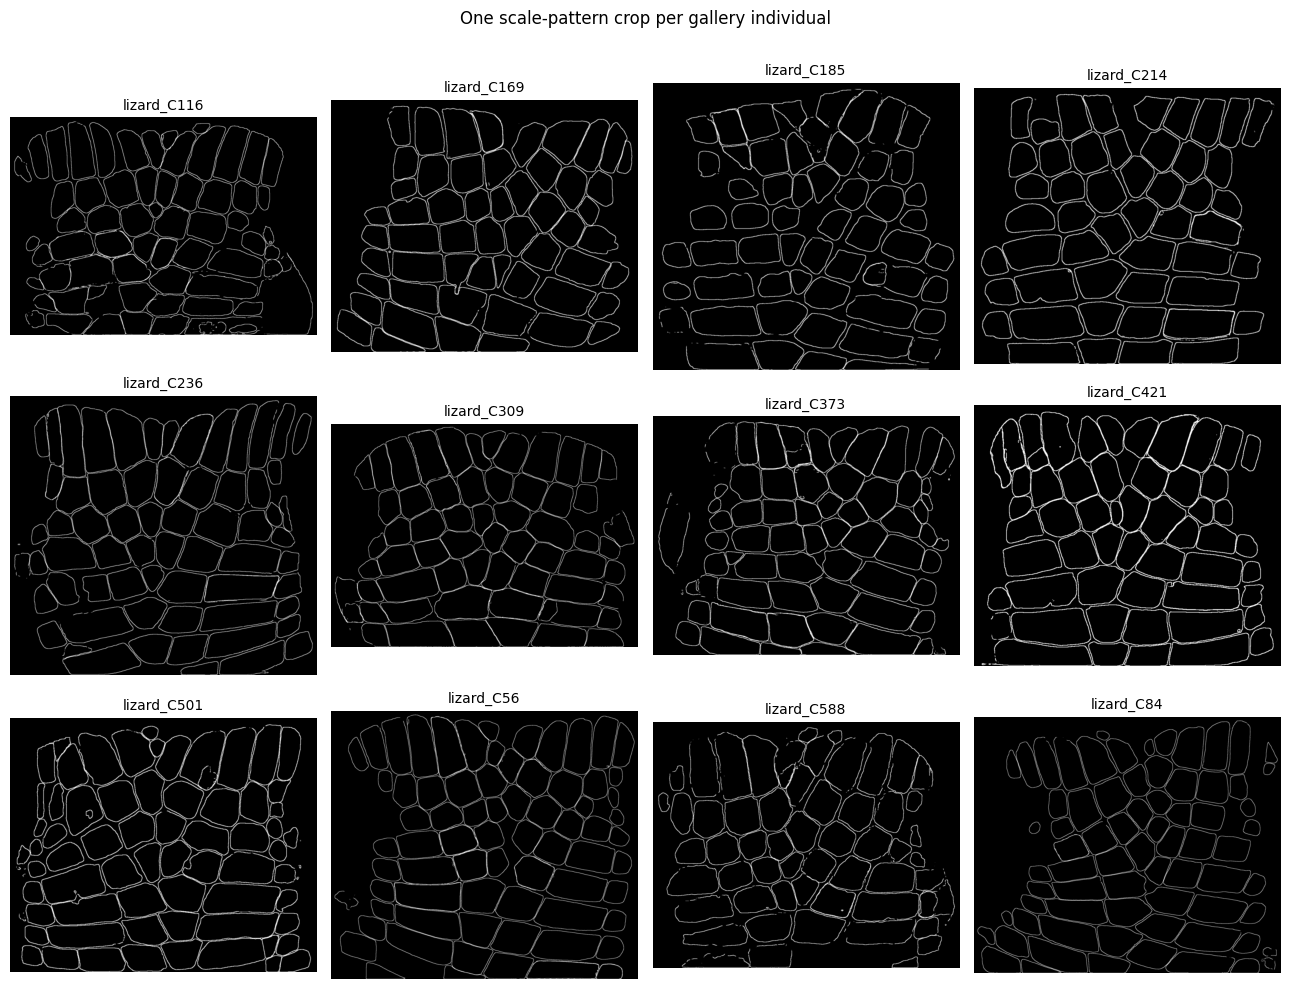

lizard_C116    4
lizard_C169    4
lizard_C185    4
lizard_C214    4
lizard_C236    4
lizard_C309    4
lizard_C373    4
lizard_C421    4
lizard_C501    4
lizard_C56     4
lizard_C588    4
lizard_C84     4


In [2]:
fig, axes = plt.subplots(3, 4, figsize=(13, 10))
for ax, ind in zip(axes.ravel(), individuals):
    ax.imshow(D.load_gray(D.list_images(PATTERN / ind)[0]), cmap="gray")
    ax.set_title(ind, fontsize=10); ax.axis("off")
plt.suptitle("One scale-pattern crop per gallery individual", y=1.005)
plt.tight_layout(); plt.show()

print(pd.Series({i: len(D.list_images(PATTERN / i)) for i in individuals},
                name="photographs").to_string())

## Stage 1 — Wireframes and matching

`TwoViewPipeline` does both in one call: SuperPoint keypoints and LSD line
segments are merged into a **wireframe** per image, then GlueStick matches two
wireframes jointly, so points and lines reinforce each other instead of being
matched independently. On a scale mosaic the lines trace the boundaries between
scales, which is exactly the structure that identifies an individual.

Images are resized to `params.IMAGE_HEIGHT_RESIZE` first. That is not tidying up:
Figures 4 and 5 of the paper show match counts climbing steeply with resolution
up to about this point, and the trained models are calibrated against it — change
it and you must retrain.

In [3]:
pipeline = D.build_pipeline(DEVICE)   # downloads GlueStick + SuperPoint on first run

print(f"keypoints per image : up to {params.WIREFRAME_CONF['sp_params']['max_num_keypoints']}")
print(f"lines per image     : up to {params.WIREFRAME_CONF['max_n_lines']}")
print(f"working height      : {params.IMAGE_HEIGHT_RESIZE} px")
print(f"match prob. filter  : {D.MATCH_PROB_THRESHOLD}")

keypoints per image : up to 1000
lines per image     : up to 300
working height      : 670 px
match prob. filter  : 0.2


### What a match looks like

The same individual, then two different ones. Both the number of surviving matches and their mean confidence should drop in the second case — that gap is the entire signal the classifier learns.

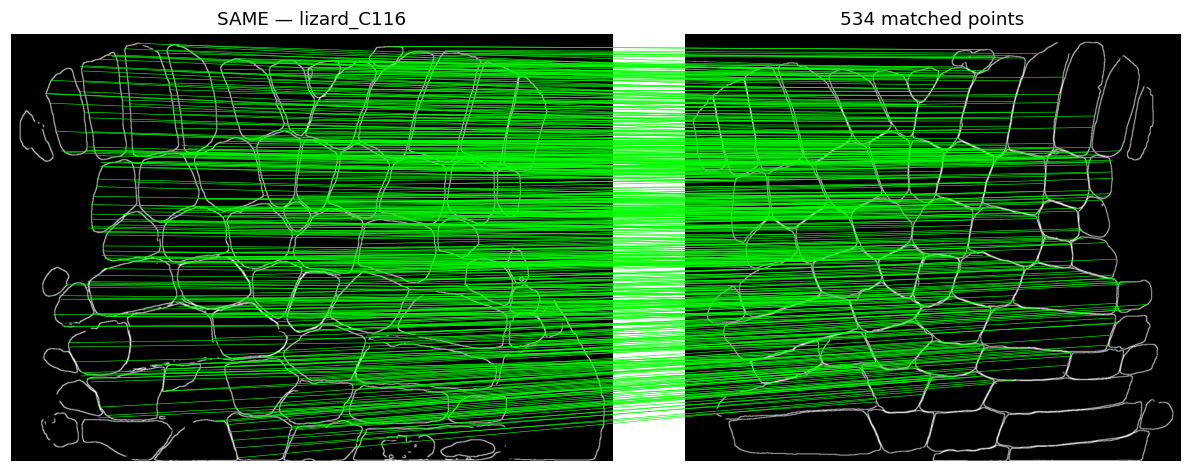

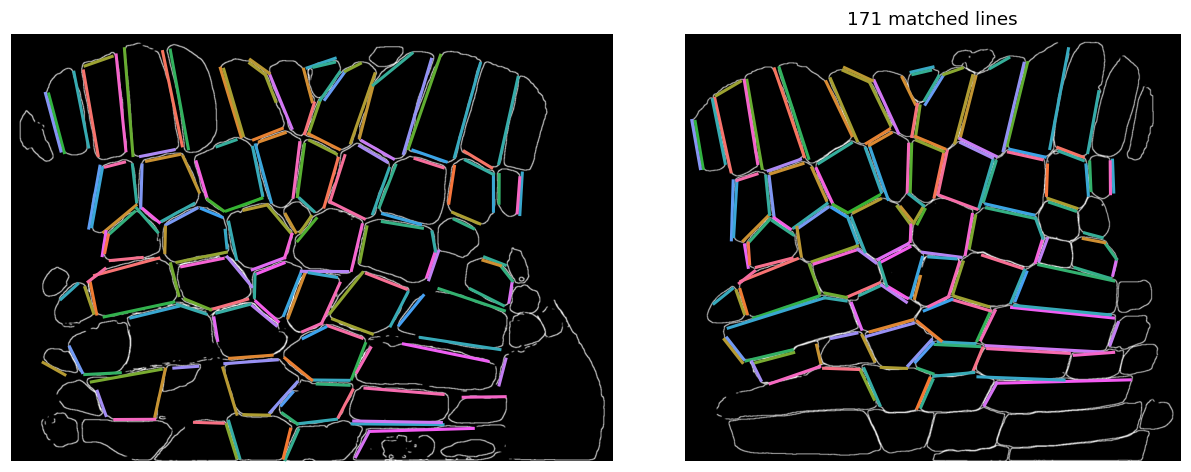

same individual      : {'num_nonzero_points': 534, 'mean_point_prob': 0.6474071145057678, 'num_nonzero_lines': 171, 'mean_line_prob': 0.5589569211006165}


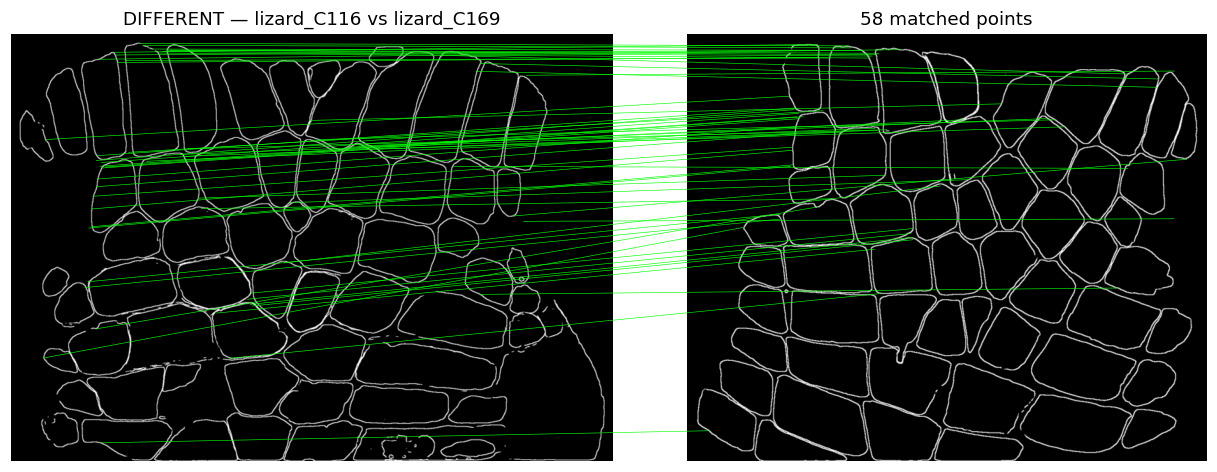

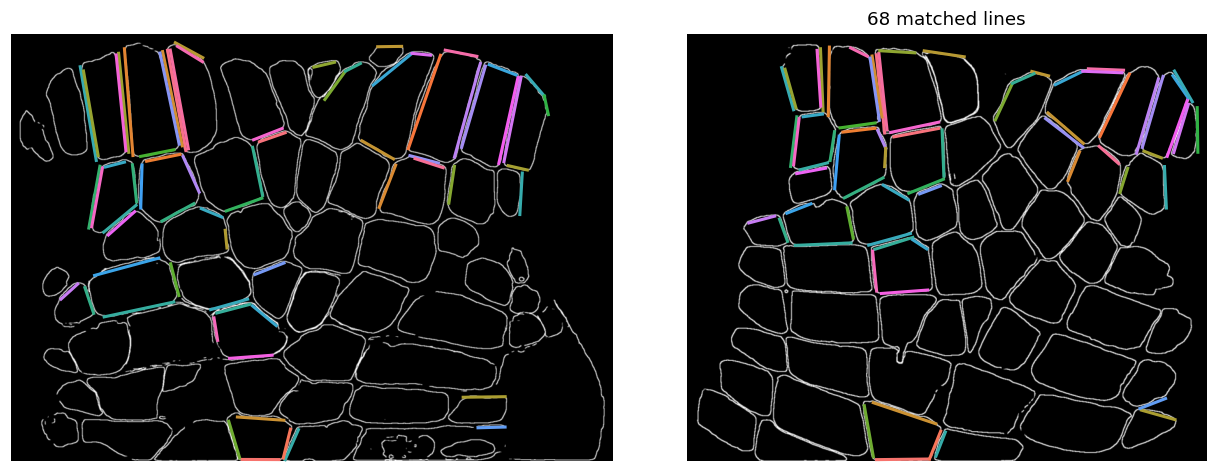

different individuals: {'num_nonzero_points': 58, 'mean_point_prob': 0.34592077136039734, 'num_nonzero_lines': 68, 'mean_line_prob': 0.3452432155609131}


In [4]:
a = D.list_images(PATTERN / individuals[0])
b = D.list_images(PATTERN / individuals[1])

pred, g0, g1 = D.match_pair(pipeline, a[0], a[1], DEVICE)
D.draw_matches(pred, g0, g1, f"SAME — {individuals[0]}")
print("same individual      :", D.pair_features(pred))

pred, g0, g1 = D.match_pair(pipeline, a[0], b[0], DEVICE)
D.draw_matches(pred, g0, g1, f"DIFFERENT — {individuals[0]} vs {individuals[1]}")
print("different individuals:", D.pair_features(pred))

### Every pair

48 images means 1 128 unordered pairs. This is the quadratic step, and the reason
`scripts/P2` caches each image's wireframe in `precomputed_wireframe.h5` — so it
is computed once and reused across all of that image's pairs — and writes match
results to a resumable LMDB store.

In [5]:
labelled = [(ind, p) for ind in individuals for p in D.list_images(PATTERN / ind)]
print(f"{len(labelled)} images -> {len(labelled)*(len(labelled)-1)//2} pairs\n")

matches = None if RUN_MATCHING else D.load_precomputed(PRECOMPUTED, labelled)
if matches is None:
    matches = D.all_pairs_table(pipeline, labelled, DEVICE)
else:
    print(f"loaded from {PRECOMPUTED} - set RUN_MATCHING = True to recompute")

print(f"\n{len(matches)} pairs: {matches['same'].sum()} same-individual, "
      f"{(~matches['same']).sum()} different")
matches.head()

48 images -> 1128 pairs

loaded from data/precomputed/lizard_demo_matches.parquet - set RUN_MATCHING = True to recompute

1128 pairs: 72 same-individual, 1056 different


,img1_full,img2_full,id1,id2,same,num_nonzero_points,mean_point_prob,num_nonzero_lines,mean_line_prob
0,lizard_C116/IMG_3943.png,lizard_C116/IMG_4133.png,lizard_C116,lizard_C116,True,534,0.647407,171,0.558957
1,lizard_C116/IMG_3943.png,lizard_C116/IMG_4204.png,lizard_C116,lizard_C116,True,561,0.634146,176,0.530733
2,lizard_C116/IMG_3943.png,lizard_C116/IMG_4328.png,lizard_C116,lizard_C116,True,498,0.639389,165,0.575768
3,lizard_C116/IMG_3943.png,lizard_C169/IMG_0251.png,lizard_C116,lizard_C169,False,64,0.346701,53,0.312430
4,lizard_C116/IMG_3943.png,lizard_C169/IMG_0344.png,lizard_C116,lizard_C169,False,72,0.282738,47,0.294707


## Near-duplicate photographs

Two genuinely different photographs of the same animal share a few hundred
keypoints at best. A pair far above that is usually not two photographs at all —
it is the same image in the gallery twice: a burst frame, a re-import, one file
saved under two names. Left in, it teaches the classifier that same-individual
pairs look near-identical, which is a comparison it will never meet in the field.

`scripts/P3-feature_aggregation.py` drops these before training and so does the
cell below. Of each flagged pair one copy is removed and one is kept, so the
animal still has a photograph in the gallery. Look at the pairs it prints: the
threshold is a heuristic, and you are the one who can tell a duplicate from a
genuinely tight match.

In [6]:
matches, dropped, dups = D.drop_duplicate_images(matches)

if dropped:
    print(f"{len(dups)} pair(s) above {D.DUPLICATE_POINT_THRESHOLD} matched points:\n")
    for _, r in dups.sort_values("num_nonzero_points", ascending=False).iterrows():
        print(f"  {r.num_nonzero_points:5.0f} pts   {r.img1_full}   <->   {r.img2_full}")
    print(f"\nremoving {len(dropped)} image(s), keeping the other copy of each:")
    for d in dropped:
        print(f"  {d}")
    print(f"\n{len(matches)} pairs left "
          f"({matches['same'].sum()} same-individual, {(~matches['same']).sum()} different)")
    D.show_duplicate_pairs(dups, PATTERN)
else:
    print(f"No pair exceeds {D.DUPLICATE_POINT_THRESHOLD} matched points - "
          "no near-duplicates in this gallery.")

matches.to_parquet(params.PROCESSED_MATCHES_FILE_PATH, index=False)

No pair exceeds 900 matched points - no near-duplicates in this gallery.


       num_nonzero_points  mean_point_prob  num_nonzero_lines  mean_line_prob
same                                                                         
False             133.346            0.319             62.920           0.313
True              461.986            0.585            154.389           0.506 



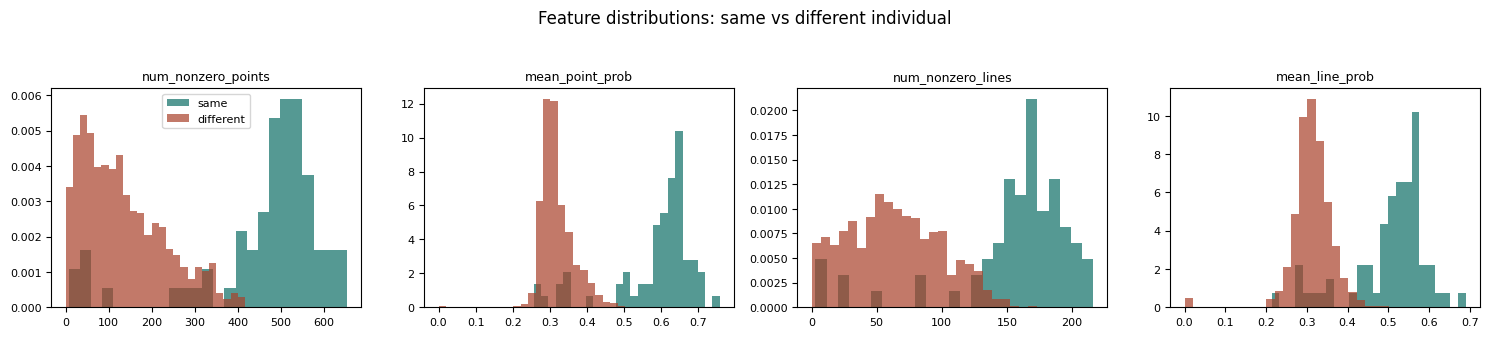

In [7]:
print(matches.groupby("same")[D.FEATURES].mean().round(3).to_string(), "\n")

fig, axes = plt.subplots(1, 4, figsize=(15, 3.2))
for ax, f in zip(axes, D.FEATURES):
    for flag, label, colour in [(True, "same", "#0d6e66"), (False, "different", "#a8412a")]:
        ax.hist(matches.loc[matches["same"] == flag, f], bins=25, alpha=.7,
                label=label, color=colour, density=True)
    ax.set_title(f, fontsize=9); ax.tick_params(labelsize=8)
axes[0].legend(fontsize=8)
plt.suptitle("Feature distributions: same vs different individual", y=1.04)
plt.tight_layout(); plt.show()

## Stage 2 — The pair-level classifier

Four candidates are compared over **image-disjoint** folds: no image appears on
both sides of a fold, so a model cannot score well by memorising a particular
photograph. Best mean F1 wins.

The paper uses 10 folds of 40 held-out images for this dataset; with 48 images we
use 3 folds of 4. Same protocol, much smaller scale — treat the numbers as a
demonstration, not a result.

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

N_FOLDS, N_HELDOUT = 3, 4
shuffled = pd.Series(pd.unique(pd.concat([matches.img1_full, matches.img2_full]))) \
             .sample(frac=1, random_state=42).tolist()
folds = [shuffled[i*N_HELDOUT:(i+1)*N_HELDOUT] for i in range(N_FOLDS)]

candidates = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_features="sqrt", random_state=42),
    "XGBoost": XGBClassifier(learning_rate=.05, n_estimators=150, max_depth=5,
                             subsample=.8, colsample_bytree=.8, eval_metric="auc", random_state=42),
    "CatBoost": CatBoostClassifier(learning_rate=.1, iterations=200, depth=5,
                                   random_state=42, verbose=0),
}

scores = {}
for name, model in candidates.items():
    fold_f1 = []
    for held in folds:
        tr = matches[~matches.img1_full.isin(held) & ~matches.img2_full.isin(held)]
        va = matches[matches.img1_full.isin(held) ^ matches.img2_full.isin(held)]
        if tr.empty or va.empty or va["same"].nunique() < 2:
            continue
        sc = StandardScaler().fit(tr[D.FEATURES])
        model.fit(sc.transform(tr[D.FEATURES]), tr["same"].astype(int))
        fold_f1.append(f1_score(va["same"].astype(int),
                                model.predict(sc.transform(va[D.FEATURES])),
                                average="macro", zero_division=0))
    scores[name] = fold_f1
    print(f"{name:22} per fold {[round(x,3) for x in fold_f1]}  mean {np.mean(fold_f1):.3f}")

best_name = max(scores, key=lambda k: np.mean(scores[k]))
print(f"\nselected: {best_name}")

Logistic Regression    per fold [1.0, 0.952, 0.952]  mean 0.968


Random Forest          per fold [1.0, 0.952, 0.977]  mean 0.976


XGBoost                per fold [1.0, 0.952, 0.977]  mean 0.976


CatBoost               per fold [1.0, 0.952, 0.93]  mean 0.961

selected: Random Forest


In [9]:
# Refit the winner on every pair, keeping the scaler that goes with it.
scaler = StandardScaler().fit(matches[D.FEATURES])
clf = candidates[best_name].fit(scaler.transform(matches[D.FEATURES]), matches["same"].astype(int))

matches["p"] = clf.predict_proba(scaler.transform(matches[D.FEATURES]))[:, 1]
print(matches.groupby("same")["p"].describe()[["mean", "50%", "max"]].round(3).to_string())

        mean  50%   max
same                   
False  0.004  0.0  0.28
True   0.937  1.0  1.00


## Stage 3 — The meta-model and τ\*

A pair probability is not yet an identity decision. For a query image and a
candidate identity, the pair probabilities across *all* of that identity's
photographs are summarised as `[p, max, mean]`, and a logistic regression turns
that triple into a calibrated identity-level score.

The threshold **τ\*** on that score is chosen to maximise F1, and is what makes
the method open-set: a query whose best score falls below it is reported as a
**new individual** rather than forced onto the nearest match.

tau* = 0.04   (F1 = 1.000)


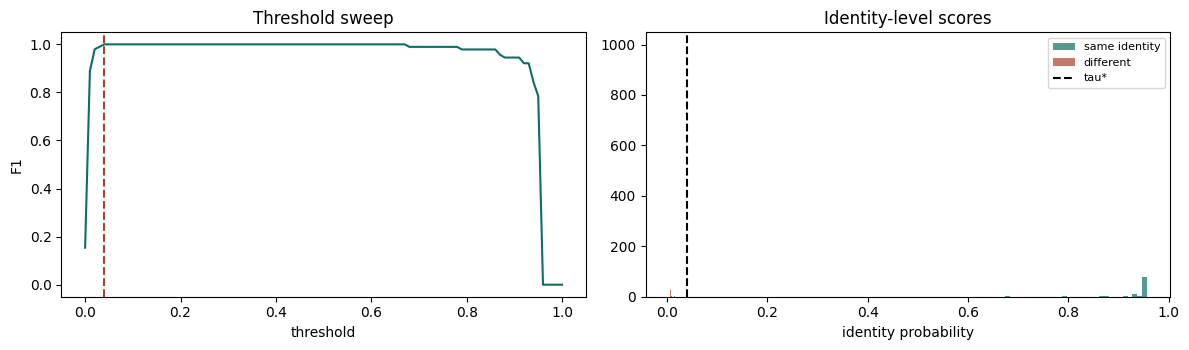

In [10]:
sym = pd.concat([
    matches.rename(columns={"img1_full": "q", "id2": "cand"})[["q", "cand", "p", "id1"]],
    matches.rename(columns={"img2_full": "q", "id1": "cand"})[["q", "cand", "p", "id2"]]
           .rename(columns={"id2": "id1"}),
], ignore_index=True)

agg = (sym.groupby(["q", "cand"])
          .agg(p=("p", "max"), mean_predicted_probability=("p", "mean"),
               max_predicted_probability=("p", "max"), true_id=("id1", "first"))
          .reset_index())
agg["same"] = agg["cand"] == agg["true_id"]

META = ["p", "max_predicted_probability", "mean_predicted_probability"]
meta = LogisticRegression(max_iter=1000).fit(agg[META].values, agg["same"].astype(int))
agg["identity_prob"] = meta.predict_proba(agg[META].values)[:, 1]

grid = np.linspace(0, 1, 101)
f1s = [f1_score(agg["same"].astype(int), (agg["identity_prob"] >= t).astype(int),
                zero_division=0) for t in grid]
tau = float(grid[int(np.argmax(f1s))])
print(f"tau* = {tau:.2f}   (F1 = {max(f1s):.3f})")

fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
ax[0].plot(grid, f1s, color="#0d6e66"); ax[0].axvline(tau, ls="--", c="#a8412a")
ax[0].set_xlabel("threshold"); ax[0].set_ylabel("F1"); ax[0].set_title("Threshold sweep")
for flag, label, colour in [(True, "same identity", "#0d6e66"), (False, "different", "#a8412a")]:
    ax[1].hist(agg.loc[agg["same"] == flag, "identity_prob"], bins=30, alpha=.7,
               label=label, color=colour, density=True)
ax[1].axvline(tau, ls="--", c="k", label="tau*"); ax[1].legend(fontsize=8)
ax[1].set_title("Identity-level scores"); ax[1].set_xlabel("identity probability")
plt.tight_layout(); plt.show()

## Save the model

Four small files, into `results/` — exactly what `scripts/P4-model_training.py`
writes and what [Demo 2](demo-2-query.ipynb) and `scripts/Q4` load.

They are **specific to this dataset**. Per-dataset retraining is deliberate, and
cheap, because only these small models change — the matching stack never does.

In [11]:
joblib.dump(scaler, params.SCALER_PATH)
joblib.dump(clf,    params.BEST_MODEL_PATH)
joblib.dump(meta,   params.LOGREG_MODEL_PATH)
Path(params.BEST_THRESHOLD_PATH).write_text(str(tau))

for f in [params.SCALER_PATH, params.BEST_MODEL_PATH, params.LOGREG_MODEL_PATH,
          params.BEST_THRESHOLD_PATH]:
    print(f"  {f:50} {os.path.getsize(f)/1024:8.1f} KB")
print(f"\npair-level model: {best_name}   tau* = {tau}")
print("\nNext: demo-2-query.ipynb")

  results/scaler.pkl                                      1.0 KB
  results/best_classification_model.pkl                 307.7 KB
  results/logistic_regression_model.pkl                   0.9 KB
  results/threshold.txt                                   0.0 KB

pair-level model: Random Forest   tau* = 0.04

Next: demo-2-query.ipynb
